In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
np.random.seed(42)
data = np.random.normal(50, 5, 100)
outliers = np.array([10, 90, 95]) 
data = np.concatenate([data, outliers])
df = pd.DataFrame(data, columns=['Valeur'])

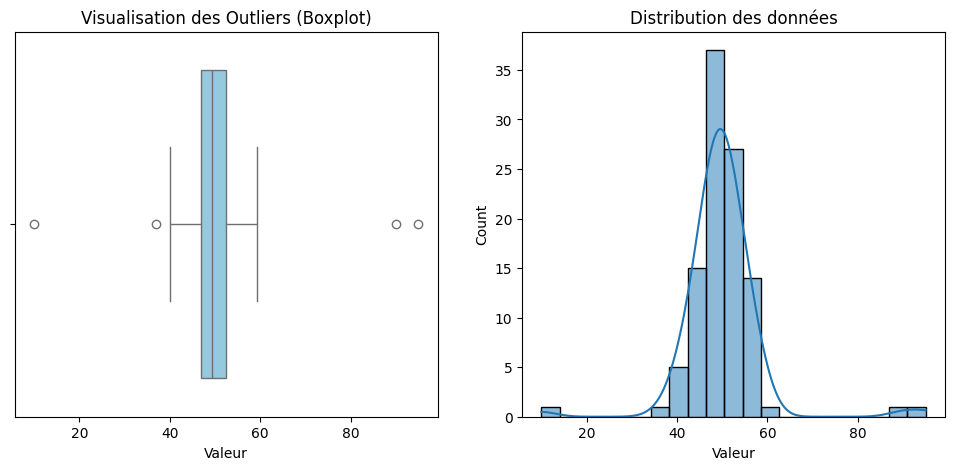

In [3]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.boxplot(x=df['Valeur'], color='skyblue')
plt.title("Visualisation des Outliers (Boxplot)")

plt.subplot(1, 2, 2)
sns.histplot(df['Valeur'], kde=True)
plt.title("Distribution des données")
plt.show()

In [4]:
Q1 = df['Valeur'].quantile(0.25)
Q3 = df['Valeur'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_iqr = df[(df['Valeur'] < lower_bound) | (df['Valeur'] > upper_bound)]
print(f"Bornes IQR : [{lower_bound:.2f} , {upper_bound:.2f}]")
print(f"Nombre d'outliers détectés (IQR) : {len(outliers_iqr)}")

Bornes IQR : [38.70 , 60.82]
Nombre d'outliers détectés (IQR) : 4


In [5]:
mean = df['Valeur'].mean()
std = df['Valeur'].std()
df['Z-Score'] = (df['Valeur'] - mean) / std
outliers_z = df[df['Z-Score'].abs() > 3]

print(f"Nombre d'outliers détectés (Z-Score > 3) : {len(outliers_z)}")

Nombre d'outliers détectés (Z-Score > 3) : 3


In [6]:
df_cleaned = df[(df['Valeur'] >= lower_bound) & (df['Valeur'] <= upper_bound)]

In [7]:
df_capped = df.copy()
df_capped['Valeur'] = np.where(df['Valeur'] > upper_bound, upper_bound,
                         np.where(df['Valeur'] < lower_bound, lower_bound, df['Valeur']))

print(f"\nDimensions après suppression : {df_cleaned.shape}")
print(f"Max après plafonnement : {df_capped['Valeur'].max():.2f}")


Dimensions après suppression : (99, 2)
Max après plafonnement : 60.82
